Using device: mps
Loading GPT-2 model and tokenizer...
Model ready on device: mps
Original dataset loaded: 30000 WikiText samples
Financial dataset loaded: 4846 samples
Kaggle-like dataset loaded: 1000 samples
Simulated multiple domain drifts:
  Drift region 1: indices 10000 to 15000 (Finance).
  Drift region 2: indices 20000 to 25000 (Kaggle).
Starting drift detection...
Batch 156: Drift detected! M_t = 4.7131, threshold = 4.4377
Inputs in this batch:
[" Zweig uncovers the roots of Marge 's fear : the moment she realized her father was not a pilot , but an apron @-@ wearing flight attendant , a job that was mostly reserved for women at the time . Her shame is eased when Zweig assures her that male flight attendants are now very common and that her father could be considered a pioneer . Marge also brings up memories of her grandmother poking her in the eye as a baby while playing airplane , a toy plane catching fire , and having a plane fire at her and her mother , but Zweig just ignor

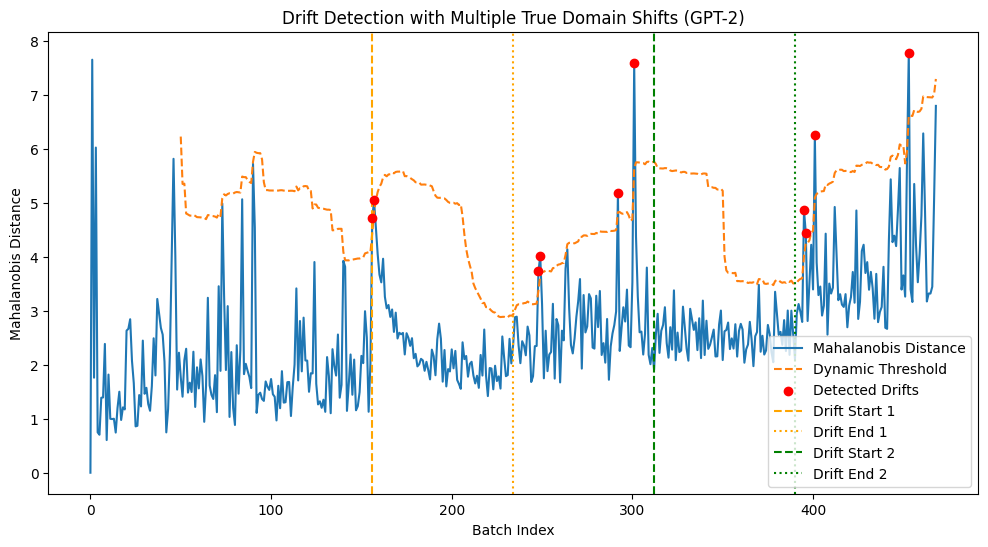

Plot saved to results/drift_detection_with_gpt2.png


In [1]:
!pip install torch transformers accelerate datasets scikit-learn numpy evidently matplotlib

import argparse
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import random

#################################
# Parse Arguments
#################################
def parse_args():
    parser = argparse.ArgumentParser(
        description="Run first-token embedding drift detection experiments with GPT-2."
    )
    parser.add_argument("--model_name", type=str,
                        default="gpt2",
                        help="HuggingFace model name (GPT-2 variant).")
    parser.add_argument("--wiki_dataset_name", type=str, default="wikitext",
                        help="HuggingFace dataset for original text.")
    parser.add_argument("--wiki_dataset_config", type=str,
                        default="wikitext-2-raw-v1",
                        help="Dataset config.")
    parser.add_argument("--wiki_split", type=str, default="train",
                        help="WikiText dataset split.")
    parser.add_argument("--financial_dataset_name", type=str,
                        default="financial_phrasebank",
                        help="HuggingFace dataset for financial domain.")
    parser.add_argument("--financial_dataset_config", type=str,
                        default="sentences_50agree",
                        help="Configuration of financial_phrasebank.")
    parser.add_argument("--financial_split", type=str, default="train",
                        help="Financial dataset split.")
    parser.add_argument("--max_texts", type=int, default=30000,
                        help="Max number of texts to use from dataset.")
    parser.add_argument("--batch_size", type=int, default=64,
                        help="Batch size.")
    parser.add_argument("--alpha", type=float, default=0.01,
                        help="Alpha for running mean/cov updates.")
    parser.add_argument("--drift_threshold_std", type=float, default=3.0,
                        help="Number of std devs for threshold.")
    parser.add_argument("--window_size", type=int, default=50,
                        help="Rolling window size for threshold computation.")
    parser.add_argument("--output_dir", type=str, default="results",
                        help="Directory to save results and plots.")
    # If running in a Jupyter/Colab environment, return default args
    args, unknown = parser.parse_known_args()
    return args

args = parse_args()

#################################
# Setup
#################################
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# Ensure output directory exists
os.makedirs(args.output_dir, exist_ok=True)

#################################
# Load Model and Tokenizer
#################################
print("Loading GPT-2 model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args.model_name)
model = AutoModel.from_pretrained(args.model_name)

# GPT-2 has no pad token by default: set pad token to EOS to allow padding
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model.to(device)
model.eval()
print("Model ready on device:", device)

#################################
# Load Original (WikiText) Dataset
#################################
wiki_dataset = load_dataset(args.wiki_dataset_name, args.wiki_dataset_config,
                            split=args.wiki_split)
texts = wiki_dataset["text"]

if args.max_texts > 0 and args.max_texts < len(texts):
    texts = texts[:args.max_texts]
print(f"Original dataset loaded: {len(texts)} WikiText samples")

#################################
# Load Financial Dataset for Drift
#################################
fin_dataset = load_dataset(args.financial_dataset_name,
                           args.financial_dataset_config,
                           split=args.financial_split)
financial_texts = fin_dataset["sentence"]
random.shuffle(financial_texts)  # Shuffle for randomness

# Simulate a second domain by using a slice of the financial texts as "Kaggle-like" data:
kaggle_texts = financial_texts[:1000]

print(f"Financial dataset loaded: {len(financial_texts)} samples")
print(f"Kaggle-like dataset loaded: {len(kaggle_texts)} samples")

#################################
# Simulate Multiple True Domain Drifts
#################################
n = len(texts)
# First drift region: from 1/3 to 1/2 (Finance)
drift_start_1 = n // 3
drift_end_1 = n // 2

# Second drift region: from 2/3 to 5/6 (Kaggle)
drift_start_2 = 2 * n // 3
drift_end_2 = 5 * n // 6

# Replace text in these regions with purely financial or kaggle text
fin_idx = 0
for i in range(drift_start_1, drift_end_1):
    if fin_idx >= len(financial_texts):
        fin_idx = 0  # wrap around if needed
    texts[i] = financial_texts[fin_idx]
    fin_idx += 1

kaggle_idx = 0
for i in range(drift_start_2, drift_end_2):
    if kaggle_idx >= len(kaggle_texts):
        kaggle_idx = 0  # wrap around if needed
    texts[i] = kaggle_texts[kaggle_idx]
    kaggle_idx += 1

print("Simulated multiple domain drifts:")
print(f"  Drift region 1: indices {drift_start_1} to {drift_end_1} (Finance).")
print(f"  Drift region 2: indices {drift_start_2} to {drift_end_2} (Kaggle).")

#################################
# Utility Functions
#################################
def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    """
    GPT-2 does not have a special [CLS] token. For consistency with
    the BERT approach, we take the hidden state corresponding to the
    first token in each sequence (index=0). Then we average those
    embeddings across the batch to get a single vector per batch.
    """
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        # last_hidden_state shape: [batch_size, seq_len, hidden_dim]
        # GPT-2's "first token" embedding is outputs.last_hidden_state[:, 0, :]
        first_token_embeddings = outputs.last_hidden_state[:, 0, :]
    # Average embedding across the batch
    return first_token_embeddings.mean(dim=0).cpu().numpy()

#################################
# Drift Detection Class
#################################
class EmbeddingTracker:
    def __init__(self, embedding_dim, alpha=0.01):
        self.alpha = alpha
        self.mean = np.zeros((embedding_dim,))
        self.cov = np.eye(embedding_dim)
        self.count = 0

    def update(self, embedding):
        if self.count == 0:
            self.mean = embedding
            self.cov = np.eye(len(embedding))
        else:
            # Update mean
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding
            # Update covariance
            diff = embedding - self.mean
            self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def mahalanobis_distance(self, embedding):
        diff = embedding - self.mean
        cov_inv = np.linalg.pinv(self.cov)
        return np.sqrt(diff.T @ cov_inv @ diff)

#################################
# Main Experiment Loop
#################################
print("Starting drift detection...")

# Get a dummy embedding to initialize tracker dimensions
dummy_embedding = extract_cls_embeddings(model, tokenizer, ["Hello world!"], device)
embedding_dim = len(dummy_embedding)
tracker = EmbeddingTracker(embedding_dim, alpha=args.alpha)

distances = []
thresholds = []
drift_points = []

for batch_index, batch_texts in enumerate(batch_generator(texts, batch_size=args.batch_size)):
    current_embedding = extract_cls_embeddings(model, tokenizer, batch_texts, device)
    tracker.update(current_embedding)
    M_t = tracker.mahalanobis_distance(current_embedding)
    distances.append(M_t)

    # Compute threshold after we have enough history
    if len(distances) > args.window_size:
        recent_dists = distances[-args.window_size:]
        mean_dist = np.mean(recent_dists)
        std_dist = np.std(recent_dists)
        threshold = mean_dist + args.drift_threshold_std * std_dist
        thresholds.append(threshold)

        if M_t > threshold:
            print(f"Batch {batch_index}: Drift detected! M_t = {M_t:.4f}, threshold = {threshold:.4f}")
            print(f"Inputs in this batch:\n{batch_texts}\n")
            drift_points.append(batch_index)
    else:
        thresholds.append(float('inf'))

#################################
# Save Results
#################################
distances_path = os.path.join(args.output_dir, "distances.npy")
thresholds_path = os.path.join(args.output_dir, "thresholds.npy")
drift_points_path = os.path.join(args.output_dir, "drift_points.npy")

np.save(distances_path, distances)
np.save(thresholds_path, thresholds)
np.save(drift_points_path, drift_points)

print(f"Distances saved to {distances_path}")
print(f"Thresholds saved to {thresholds_path}")
print(f"Drift points saved to {drift_points_path}")

#################################
# Compute FPR, TPR, Latency
#################################

# 1) Generate ground-truth drift labels per batch
num_batches = len(distances)
gt_labels = np.zeros(num_batches, dtype=int)  # 0 = no drift, 1 = drift

def mark_drift_region(start_idx, end_idx):
    # Convert text indices to batch indices
    start_batch = start_idx // args.batch_size
    end_batch = (end_idx - 1) // args.batch_size  # inclusive
    for b in range(start_batch, end_batch + 1):
        gt_labels[b] = 1

mark_drift_region(drift_start_1, drift_end_1)
mark_drift_region(drift_start_2, drift_end_2)

# 2) Generate predicted labels (1 if drift detected)
pred_labels = np.zeros(num_batches, dtype=int)
for b in drift_points:
    pred_labels[b] = 1

# 3) Confusion matrix: TP, FP, TN, FN
def confusion_matrix_elements(y_true, y_pred):
    assert len(y_true) == len(y_pred)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, FP, TN, FN

TP, FP, TN, FN = confusion_matrix_elements(gt_labels, pred_labels)

# 4) Calculate TPR, FPR
if (TP + FN) > 0:
    TPR = TP / (TP + FN)  # recall
else:
    TPR = 0.0

if (FP + TN) > 0:
    FPR = FP / (FP + TN)
else:
    FPR = 0.0

print("\n=== Drift Detection Metrics ===")
print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
print(f"TPR (Recall): {TPR:.4f}")
print(f"FPR: {FPR:.4f}")

# 5) Compute detection latency
#
# Latency = (the first time we detect drift in that region) - region_start_batch
#
def compute_latency(start_idx, end_idx):
    start_batch = start_idx // args.batch_size
    end_batch = (end_idx - 1) // args.batch_size
    region_batches = range(start_batch, end_batch + 1)
    # Find earliest detected drift in that region
    detected_batches = [b for b in drift_points if b in region_batches]
    if len(detected_batches) == 0:
        return None
    else:
        return min(detected_batches) - start_batch

latency_1 = compute_latency(drift_start_1, drift_end_1)
latency_2 = compute_latency(drift_start_2, drift_end_2)

print(f"Latency for drift region 1: {latency_1} batches")
print(f"Latency for drift region 2: {latency_2} batches")

latencies = [l for l in [latency_1, latency_2] if l is not None]
avg_latency = sum(latencies) / len(latencies) if latencies else None
print(f"Average latency: {avg_latency} batches\n")

#################################
# Visualization
#################################
plt.figure(figsize=(12, 6))
plt.plot(distances, label="Mahalanobis Distance")
plt.plot(thresholds, label="Dynamic Threshold", linestyle="--")

# Highlight detected drift points
if drift_points:
    plt.scatter(drift_points,
                [distances[i] for i in drift_points],
                color="red", label="Detected Drifts", zorder=5)

# Mark simulated drift regions
plt.axvline(x=drift_start_1 // args.batch_size, color="orange", linestyle="--", label="Drift Start 1")
plt.axvline(x=drift_end_1 // args.batch_size, color="orange", linestyle=":", label="Drift End 1")
plt.axvline(x=drift_start_2 // args.batch_size, color="green", linestyle="--", label="Drift Start 2")
plt.axvline(x=drift_end_2 // args.batch_size, color="green", linestyle=":", label="Drift End 2")

plt.xlabel("Batch Index")
plt.ylabel("Mahalanobis Distance")
plt.title("Drift Detection with Multiple True Domain Shifts (GPT-2)")
plt.legend()

plot_path = os.path.join(args.output_dir, "drift_detection_with_gpt2.png")
plt.savefig(plot_path)
plt.show()
print(f"Plot saved to {plot_path}")
